In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import csv
import joblib
import warnings

warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

BASE_PATH_RVES = "./rves"
BASE_PATH_CURVES = "./strain-stress"

N_STRAIN_POINTS = 201
TOTAL_SAMPLES = 67
N_TRAIN = 55
N_TEST = 12
SHAPE = (100, 100, 100)

os.environ['TF_NUM_INTRAOP_THREADS'] = '12'
os.environ['TF_NUM_INTEROP_THREADS'] = '12'

I0000 00:00:1779873948.149911  102513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779873948.193330  102513 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779873949.215624  102513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
from scipy.interpolate import interp1d
import os
import csv
import numpy as np

def read_metadata(folder_path):
    """
    Считывает объемную долю волокна (Vf) из файла metadata.csv в папке RVE.
    
    Args:
        folder_path (str): Путь к папке с данными RVE.
        
    Returns:
        float: Значение параметра 'actual_volume_fraction_%' или 0.0, если файл отсутствует.
    """
    meta_path = os.path.join(folder_path, "metadata.csv")
    vol_frac = 0.0
    if not os.path.exists(meta_path): return vol_frac
    with open(meta_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get('parameter') == 'actual_volume_fraction_%':
                try: vol_frac = float(row.get('value', 0))
                except ValueError: pass
                break
    return vol_frac

def read_rve_from_folder(folder_path, shape):
    """
    Загружает 3D-массив плотности RVE из набора CSV-файлов (по одному файлу на слой Z).
    Автоматически адаптируется под разные варианты именования файлов слоев.
    
    Args:
        folder_path (str): Путь к папке со слоями.
        shape (tuple): Ожидаемые размеры массива (nx, ny, nz).
        
    Returns:
        np.ndarray: 3D-массив плотности (float32).
    """
    rve = np.zeros(shape, dtype=np.float32)
    base_name = os.path.basename(folder_path)
    for z in range(shape[2]):
        # Пробуем разные варианты именования файлов слоев
        layer_file = os.path.join(folder_path, f"{base_name}_layer_{z+1}.csv")
        if not os.path.exists(layer_file):
            layer_file = os.path.join(folder_path, f"rve_layer_{z+1}.csv")
        if not os.path.exists(layer_file):
             layer_file = os.path.join(folder_path, f"layer_{z+1}.csv")
        
        if not os.path.exists(layer_file):
            raise FileNotFoundError(f"Слой {z+1} не найден в {folder_path}")
            
        try:
            # Быстрая загрузка через numpy
            layer = np.loadtxt(layer_file, delimiter=',', dtype=np.float32)
            if layer.shape == (shape[0], shape[1]):
                rve[:, :, z] = layer
            else:
                raise ValueError("Shape mismatch in fast load")
        except Exception:
             # Резервный метод загрузки через csv.reader для сложных форматов
             with open(layer_file, 'r') as f:
                reader = csv.reader(f)
                layer_data = [[float(x) for x in row if x.strip()] for row in reader if len([x for x in row if x.strip()]) == shape[1]]
                if layer_data: rve[:, :, z] = np.array(layer_data, dtype=np.float32)
    return rve

def read_curve(csv_path):
    """
    Читает данные кривой напряжение-деформация из CSV файла.
    
    Args:
        csv_path (str): Путь к файлу кривой.
        
    Returns:
        tuple: Массивы (strain, stress).
    """
    try: data = np.loadtxt(csv_path, delimiter=',', skiprows=1, encoding='utf-8-sig')
    except: data = np.loadtxt(csv_path, delimiter=';', skiprows=1, encoding='utf-8-sig')
    if data.ndim == 1: data = data.reshape(-1, 2)
    return data[:, 0], data[:, 1]

def resample_curve(strain, stress, target_strain_grid):
    """
    Интерполирует кривую напряжение-деформация на единую сетку деформаций.
    
    Args:
        strain (np.array): Исходные значения деформации.
        stress (np.array): Исходные значения напряжения.
        target_strain_grid (np.array): Целевая равномерная сетка деформаций.
        
    Returns:
        np.array: Пересчитанные значения напряжения на целевой сетке.
    """
    unique_indices = np.unique(strain, return_index=True)[1]
    f = interp1d(strain[unique_indices], stress[unique_indices], kind='linear', 
                 fill_value=(stress[unique_indices][0], stress[unique_indices][-1]), bounds_error=False)
    return np.maximum(f(target_strain_grid), 0)

In [ ]:
def load_data_no_aug():
    """
    Загружает обучающую и тестовую выборки без аугментации данных.
    Выполняет нормализацию RVE по максимуму и ресемплинг кривых на общую сетку.
    
    Returns:
        tuple: (X_train_rve, X_train_meta, y_train, X_test_rve, X_test_meta, y_test, strain_grid)
    """
    all_indices = list(range(1, TOTAL_SAMPLES + 1))
    train_indices = all_indices[:N_TRAIN]
    test_indices = all_indices[N_TRAIN:]
    
    strain_grid = np.linspace(0, 0.15, N_STRAIN_POINTS)
    
    X_train_rve, X_train_meta, y_train = [], [], []
    for i in train_indices:
        rve_folder = os.path.join(BASE_PATH_RVES, f"rve_csv{i}")
        curve_files = [
            os.path.join(BASE_PATH_CURVES, f"strain-stress{i}.csv"),
            os.path.join(BASE_PATH_CURVES, f"strain_stress{i}.csv")
        ]
        curve_file = next((f for f in curve_files if os.path.exists(f)), None)
        
        if not os.path.isdir(rve_folder) or curve_file is None: continue
        
        try:
            rve_raw = read_rve_from_folder(rve_folder, SHAPE)
            rve_max = np.max(rve_raw)
            rve_norm = rve_raw / rve_max if rve_max > 0 else rve_raw
            
            vol_frac = read_metadata(rve_folder)
            s, t = read_curve(curve_file)
            stress_res = resample_curve(s, t, strain_grid)
            
            X_train_rve.append(rve_norm)
            X_train_meta.append([vol_frac])
            y_train.append(stress_res)
            
        except Exception as e: print(f"Ошибка {i}: {e}")

    X_test_rve, X_test_meta, y_test = [], [], []
    for i in test_indices:
        rve_folder = os.path.join(BASE_PATH_RVES, f"rve_csv{i}")
        curve_files = [
            os.path.join(BASE_PATH_CURVES, f"strain-stress{i}.csv"),
            os.path.join(BASE_PATH_CURVES, f"strain_stress{i}.csv")
        ]
        curve_file = next((f for f in curve_files if os.path.exists(f)), None)
        
        if not os.path.isdir(rve_folder) or curve_file is None: continue
        
        try:
            rve_raw = read_rve_from_folder(rve_folder, SHAPE)
            rve_max = np.max(rve_raw)
            rve_norm = rve_raw / rve_max if rve_max > 0 else rve_raw
            
            vol_frac = read_metadata(rve_folder)
            s, t = read_curve(curve_file)
            stress_res = resample_curve(s, t, strain_grid)
            
            X_test_rve.append(rve_norm)
            X_test_meta.append([vol_frac])
            y_test.append(stress_res)
        except Exception as e: print(f"Ошибка {i}: {e}")
        
    X_train_rve = np.array(X_train_rve)[..., np.newaxis]
    y_train = np.array(y_train)
    X_test_rve = np.array(X_test_rve)[..., np.newaxis]
    y_test = np.array(y_test)
    
    print(f"Train: {X_train_rve.shape}, Test: {X_test_rve.shape}")
    return X_train_rve, np.array(X_train_meta), y_train, X_test_rve, np.array(X_test_meta), y_test, strain_grid

# Загрузка данных
X_train_rve, X_train_meta, y_train, X_test_rve, X_test_meta, y_test, strain_grid = load_data_no_aug()

Train: (55, 100, 100, 100, 1), Test: (12, 100, 100, 100, 1)


In [ ]:
class HybridCNN_GPR:
    """
    Гибридная модель, сочетающая 3D-CNN для извлечения пространственных признаков из RVE 
    и ансамбль Gaussian Process Regressors (GPR) для предсказания кривой с оценкой неопределенности.
    """
    def __init__(self, input_shape_rve, n_meta_features=1, n_strain_points=201, latent_dim_cnn=32, random_state=42):
        """
        Инициализация модели.
        
        Args:
            input_shape_rve (tuple): Форма входного тензора RVE (например, (100, 100, 100, 1)).
            n_meta_features (int): Количество мета-признаков (например, Vf).
            n_strain_points (int): Количество точек в выходной кривой.
            latent_dim_cnn (int): Размерность латентного вектора CNN.
        """
        self.n_strain_points = n_strain_points
        self.latent_dim_cnn = latent_dim_cnn
        self.random_state = random_state
        self.n_meta_features = n_meta_features
        self.extractor = None
        self.gpr_models = []
        self.scaler_features = StandardScaler()
        self.scaler_target = StandardScaler()
        self._build_extractor(input_shape_rve)

    def _build_extractor(self, input_shape_rve):
        """
        Строит архитектуру 3D-CNN экстрактора признаков.
        Архитектура: Conv3D -> MaxPool -> Conv3D -> MaxPool -> Conv3D -> MaxPool -> GAP -> Dense -> Dropout -> Latent.
        """
        inputs_rve = layers.Input(shape=input_shape_rve, name='rve_input')
        x = layers.Conv3D(16, 3, activation='relu', padding='same')(inputs_rve)
        x = layers.MaxPool3D(2)(x)
        x = layers.Conv3D(32, 3, activation='relu', padding='same')(x)
        x = layers.MaxPool3D(2)(x)
        x = layers.Conv3D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPool3D(2)(x)
        x = layers.GlobalAveragePooling3D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        cnn_latent = layers.Dense(self.latent_dim_cnn, activation='linear', name='cnn_latent')(x)
        self.extractor = models.Model(inputs_rve, cnn_latent)

    def train_extractor(self, X_rve_train, X_meta_train, y_train, X_rve_val, X_meta_val, y_val, epochs=100, batch_size=8, patience=20):
        """
        Обучает CNN-экстрактор с использованием временной головы (Dense) для минимизации MSE.
        После обучения голова удаляется, остаются только веса экстрактора.
        """
        cnn_output = self.extractor.output
        meta_in = layers.Input(shape=(self.n_meta_features,), name='meta_input')
        combined = layers.Concatenate()([cnn_output, meta_in])
        head = layers.Dense(128, activation='relu')(combined)
        head = layers.Dense(self.n_strain_points, activation='linear', name='temp_output')(head)
        
        temp_model = models.Model(inputs=[self.extractor.input, meta_in], outputs=head)
        temp_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
        
        early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1)
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
        
        history = temp_model.fit(
            [X_rve_train, X_meta_train], y_train,
            validation_data=([X_rve_val, X_meta_val], y_val),
            epochs=epochs, batch_size=batch_size,
            callbacks=[early_stop, reduce_lr], verbose=1
        )
        del temp_model
        return history

    def extract_combined_features(self, X_rve, X_meta):
        """
        Извлекает латентные признаки из CNN и объединяет их с мета-данными.
        """
        cnn_latents = self.extractor.predict(X_rve, verbose=0)
        return np.hstack([cnn_latents, X_meta])

    def train_gpr_heads(self, X_rve_train, X_meta_train, y_train):
        """
        Обучает ансамбль GPR-моделей (по одной на каждую точку деформации) 
        на извлеченных признаках.
        """
        Z_train = self.extract_combined_features(X_rve_train, X_meta_train)
        Z_scaled = self.scaler_features.fit_transform(Z_train)
        y_scaled = self.scaler_target.fit_transform(y_train)
        
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
        
        self.gpr_models = []
        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(1e-2)
        
        for i in range(self.n_strain_points):
            gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=2, normalize_y=False, random_state=self.random_state)
            gpr.fit(Z_scaled, y_scaled[:, i])
            self.gpr_models.append(gpr)

    def predict_with_uncertainty(self, X_rve_new, X_meta_new):
        """
        Предсказывает кривую напряжение-деформация и возвращает среднее значение и стандартное отклонение.
        """
        Z_new = self.extract_combined_features(X_rve_new, X_meta_new)
        Z_scaled = self.scaler_features.transform(Z_new)
        means, stds = [], []
        for gpr in self.gpr_models:
            m, s = gpr.predict(Z_scaled, return_std=True)
            means.append(m); stds.append(s)
        
        mean_curve = self.scaler_target.inverse_transform(np.column_stack(means))
        std_curve = np.column_stack(stds) * self.scaler_target.scale_
        return mean_curve, std_curve

    def save(self, path):
        """Сохраняет обученную модель и скалеры на диск."""
        os.makedirs(path, exist_ok=True)
        self.extractor.save(os.path.join(path, 'cnn_extractor.keras'))
        joblib.dump(self.gpr_models, os.path.join(path, 'gpr_heads.pkl'))
        joblib.dump(self.scaler_features, os.path.join(path, 'scaler_features.pkl'))
        joblib.dump(self.scaler_target, os.path.join(path, 'scaler_target.pkl'))

In [ ]:
model_cnn = HybridCNN_GPR(input_shape_rve=(100, 100, 100, 1), n_meta_features=1, latent_dim_cnn=32)

if len(X_train_rve) > 5:
    X_tr_rve, X_val_rve, X_tr_meta, X_val_meta, y_tr, y_val = train_test_split(
        X_train_rve, X_train_meta, y_train, test_size=0.2, random_state=42
    )
else:
    X_tr_rve, X_val_rve = X_train_rve, X_train_rve
    X_tr_meta, X_val_meta = X_train_meta, X_train_meta
    y_tr, y_val = y_train, y_train

history_cnn = model_cnn.train_extractor(X_tr_rve, X_tr_meta, y_tr, X_val_rve, X_val_meta, y_val, epochs=100, batch_size=8, patience=20)

model_cnn.train_gpr_heads(X_train_rve, X_train_meta, y_train)

E0000 00:00:1779873954.151453  102513 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779873954.151687  102781 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779873954.167605  102513 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 32s 5s/step - loss: 383855.7188 - mae: 578.4919 - val_loss: 373794.9062 - val_mae: 568.3056 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - loss: 378837.6875 - mae: 574.2833 - val_loss: 363893.4688 - val_mae: 559.7109 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step - loss: 357620.1562 - mae: 555.7291 - val_loss: 309906.5938 - val_mae: 510.3156 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step - loss: 250970.5156 - mae: 450.7255 - val_loss: 115610.2500 - val_mae: 286.5606 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - loss: 101081.2969 - mae: 260.7569 - val_loss: 66034.5547 - val_mae: 209.4551 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - loss: 46865.3398 - mae: 168.2049 - val_loss: 38365.7031 - val_mae: 163.5802 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - loss: 31543.3320 - mae: 145.7026 -

W0000 00:00:1779875657.532696  102798 cpu_allocator_impl.cc:82] Allocation of 2048000000 exceeds 10% of free system memory.
W0000 00:00:1779875659.286503  102801 cpu_allocator_impl.cc:82] Allocation of 1472000000 exceeds 10% of free system memory.


MAE: 10.4233 | RMSE: 15.9101 | R2: 0.9944 | MAPE: 1.55%


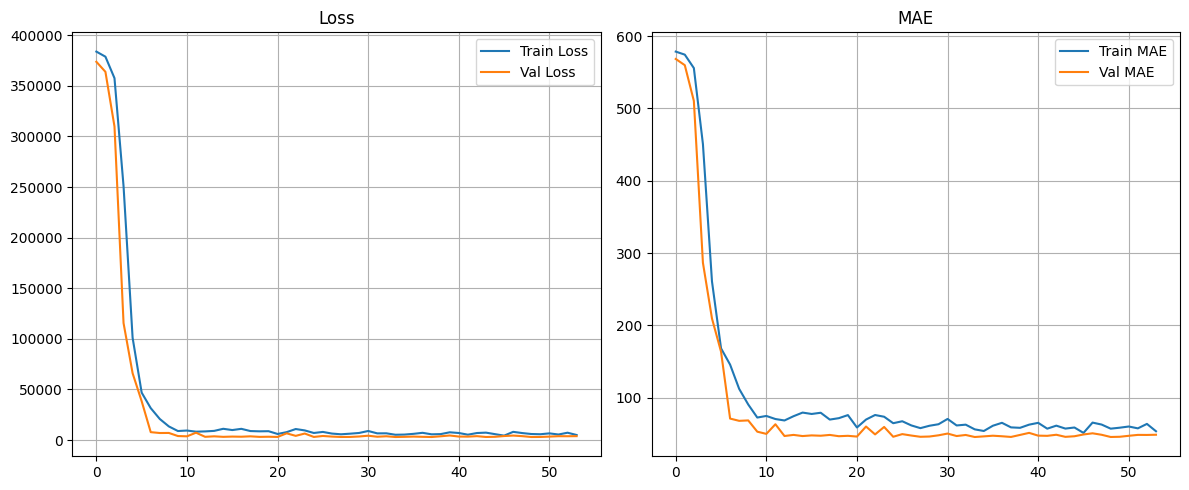

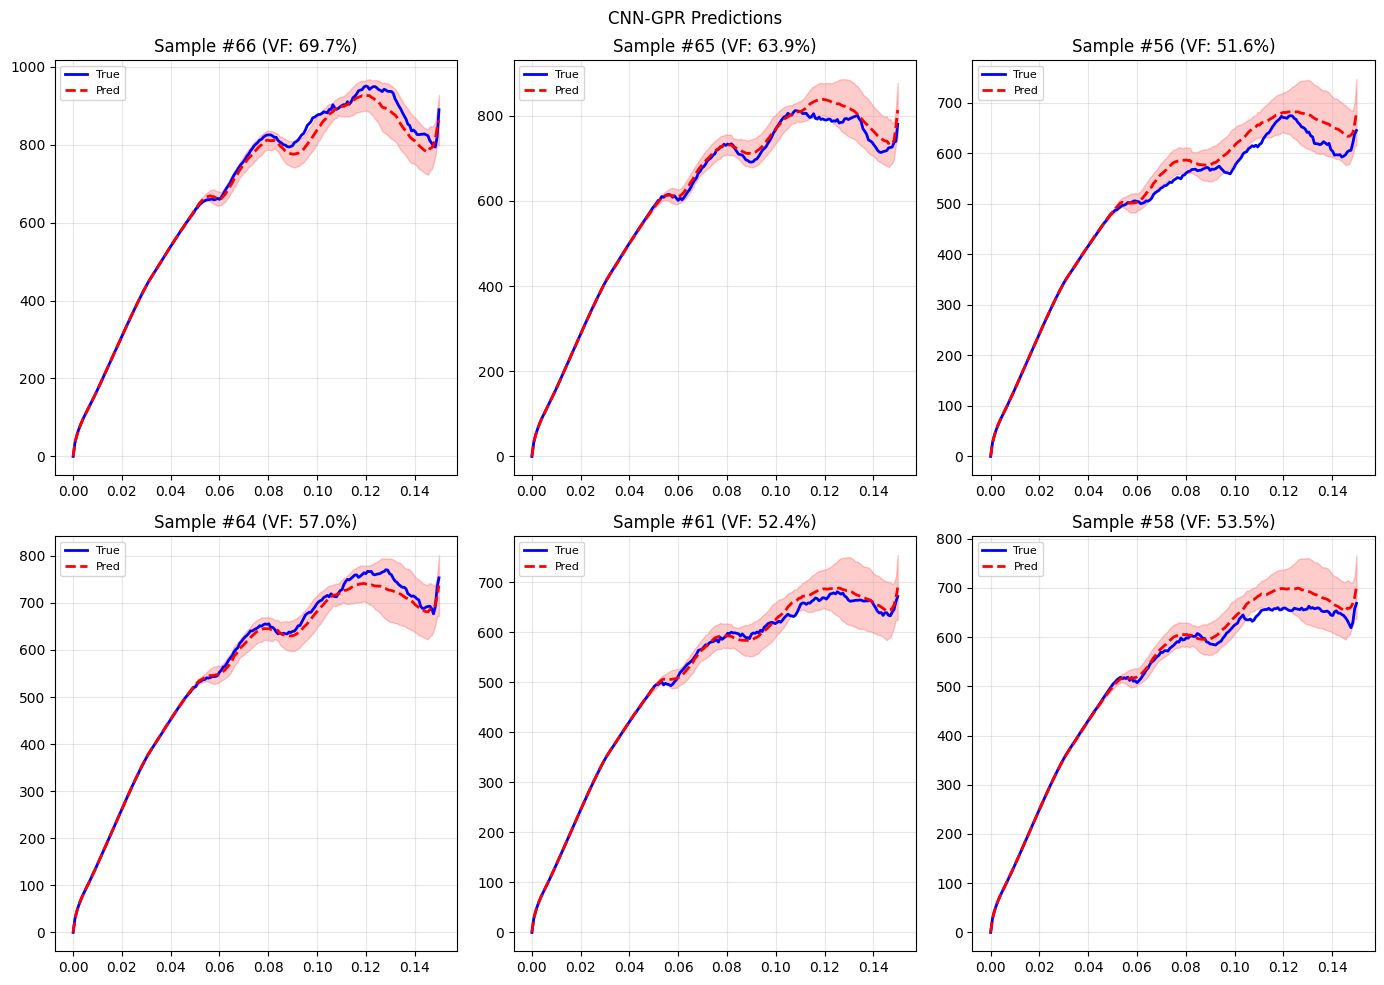

In [ ]:
# Получение предсказаний для тестовой выборки
mean_curve, std_curve = model_cnn.predict_with_uncertainty(X_test_rve, X_test_meta)

# Расчет метрик качества регрессии
y_true_flat = y_test.flatten()
y_pred_flat = mean_curve.flatten()
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2 = r2_score(y_true_flat, y_pred_flat)
mask = y_true_flat != 0
mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100 if np.any(mask) else 0.0

print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | MAPE: {mape:.2f}%")

# Визуализация процесса обучения (Loss и MAE)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss'); plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['mae'], label='Train MAE'); plt.plot(history_cnn.history['val_mae'], label='Val MAE')
plt.title('MAE'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# Визуализация предсказаний на тестовых примерах с доверительными интервалами
n_plots = min(6, len(X_test_rve))
indices = np.random.choice(len(X_test_rve), size=n_plots, replace=False)
plt.figure(figsize=(14, 10))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.plot(strain_grid, y_test[idx], 'b-', lw=2, label='True')
    plt.plot(strain_grid, mean_curve[idx], 'r--', lw=2, label='Pred')
    # Доверительный интервал 95% (mean +/- 1.96*std)
    plt.fill_between(strain_grid, mean_curve[idx]-1.96*std_curve[idx], mean_curve[idx]+1.96*std_curve[idx], color='red', alpha=0.2)
    plt.title(f'Sample #{idx+N_TRAIN+1} (VF: {X_test_meta[idx][0]:.1f}%)')
    plt.legend(loc='best', fontsize=8); plt.grid(True, alpha=0.3)
plt.suptitle('CNN-GPR Predictions'); plt.tight_layout(); plt.show()

In [ ]:
model_cnn.save('cnn_gpr')